In [3]:
import pandas as pd

df = pd.read_csv("./dataset/cicids2017_cleaned.csv")

print(len(df))

2520751


In [ ]:
print(df['Attack Type'].value_counts())


Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64
Attack Type
Normal Traffic    0.831124
DoS               0.076860
DDoS              0.050784
Port Scanning     0.035979
Brute Force       0.003630
Web Attacks       0.000850
Bots              0.000773
Name: proportion, dtype: float64


In [10]:
classes = [
'Normal Traffic',
'DoS',
'DDoS',
'Brute Force'
]

df = df[df['Attack Type'].isin(classes)]


In [11]:
print(df['Attack Type'].value_counts())

Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Brute Force          9150
Name: count, dtype: int64


1️⃣ Balanced Dataset (9000 / class)

In [12]:
import pandas as pd

# ลบ space ในชื่อ column
df.columns = df.columns.str.strip()

# แยกแต่ละ class
normal = df[df['Attack Type'] == 'Normal Traffic']
dos = df[df['Attack Type'] == 'DoS']
ddos = df[df['Attack Type'] == 'DDoS']
brute = df[df['Attack Type'] == 'Brute Force']

# sample ให้เหลือ 9000
normal = normal.sample(n=9000, random_state=42)
dos = dos.sample(n=9000, random_state=42)
ddos = ddos.sample(n=9000, random_state=42)
brute = brute.sample(n=9000, random_state=42)

# รวม dataset
df_balanced = pd.concat([normal, dos, ddos, brute])

# shuffle dataset
df_balanced = df_balanced.sample(frac=1, random_state=42)

# ตรวจสอบผล
print(df_balanced['Attack Type'].value_counts())
print(df_balanced.shape)


Attack Type
DoS               9000
DDoS              9000
Normal Traffic    9000
Brute Force       9000
Name: count, dtype: int64
(36000, 53)


In [13]:
df_balanced.to_csv("./dataset/cicids2017_balanced.csv", index=False)


2️⃣ Encode Label

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_balanced['Attack Type'] = le.fit_transform(df_balanced['Attack Type'])

print(le.classes_)


['Brute Force' 'DDoS' 'DoS' 'Normal Traffic']


3️⃣ Train / Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df_balanced.drop('Attack Type', axis=1)
y = df_balanced['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (28800, 52)
Test: (7200, 52)


4️⃣ Train Models

Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Naive Bayes

In [17]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Support Vector Machine

In [18]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Gradient Boosting

In [19]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

5️⃣ Evaluate Models

In [21]:
from sklearn.metrics import classification_report

models = {
    "Random Forest": rf,
    "Naive Bayes": nb,
    "SVM": svm,
    "Gradient Boost": gb
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n====================")
    print(name)
    print("====================")

    print(classification_report(y_test, y_pred))



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1784
           1       1.00      1.00      1.00      1778
           2       1.00      1.00      1.00      1775
           3       1.00      1.00      1.00      1863

    accuracy                           1.00      7200
   macro avg       1.00      1.00      1.00      7200
weighted avg       1.00      1.00      1.00      7200


Naive Bayes
              precision    recall  f1-score   support

           0       0.59      1.00      0.74      1784
           1       0.57      0.82      0.68      1778
           2       0.80      0.45      0.58      1775
           3       0.89      0.28      0.43      1863

    accuracy                           0.64      7200
   macro avg       0.71      0.64      0.61      7200
weighted avg       0.71      0.64      0.60      7200


SVM
              precision    recall  f1-score   support

           0       0.98      0.76      0.8

Confusion Matrix

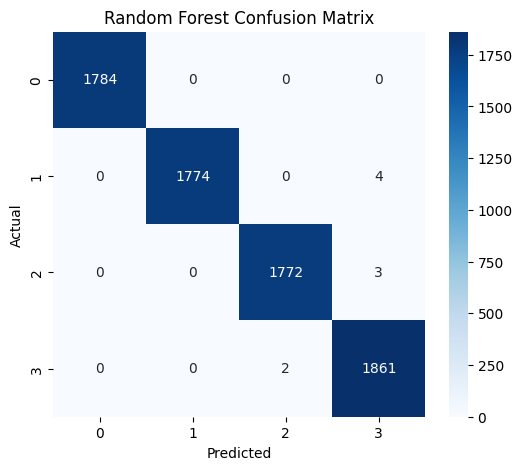

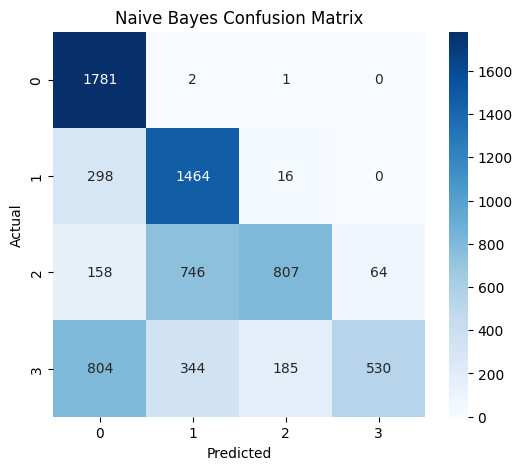

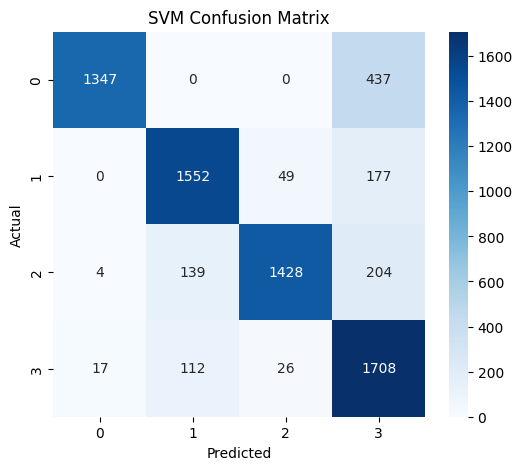

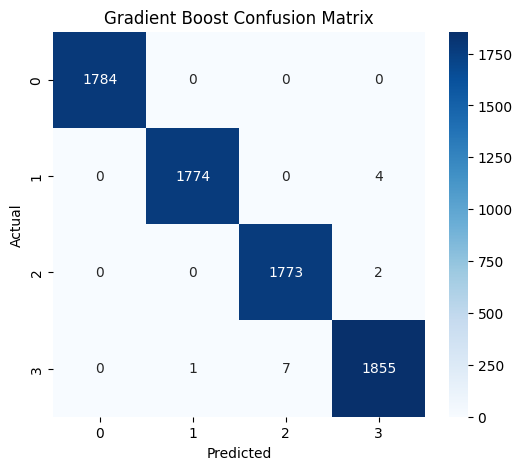

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Random Forest": rf,
    "Naive Bayes": nb,
    "SVM": svm,
    "Gradient Boost": gb
}

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


กราฟเปรียบเทียบ Accuracy

In [23]:
from sklearn.metrics import accuracy_score

accuracy_results = {}

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy_results[name] = acc

print(accuracy_results)


{'Random Forest': 0.99875, 'Naive Bayes': 0.6363888888888889, 'SVM': 0.8381944444444445, 'Gradient Boost': 0.9980555555555556}


สร้างกราฟเปรียบเทียบ

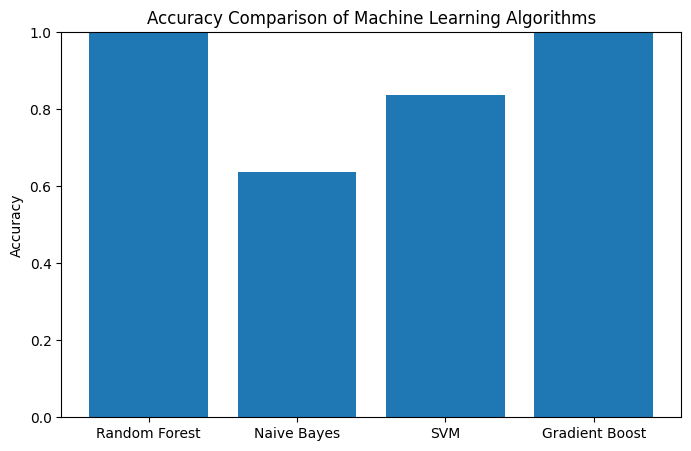

In [24]:
import matplotlib.pyplot as plt

names = list(accuracy_results.keys())
values = list(accuracy_results.values())

plt.figure(figsize=(8,5))

plt.bar(names, values)

plt.title("Accuracy Comparison of Machine Learning Algorithms")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.show()


เก็บค่าของ Metrics ทุกโมเดล

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, acc, pre, rec, f1])


สร้าง DataFrame สำหรับแสดงผล

In [26]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)

print(results_df)


            Model  Accuracy  Precision    Recall  F1-score
0   Random Forest  0.998750   0.998752  0.998750  0.998750
1     Naive Bayes  0.636389   0.714601  0.636389  0.604304
2             SVM  0.838194   0.865725  0.838194  0.842003
3  Gradient Boost  0.998056   0.998057  0.998056  0.998056


กราฟเปรียบเทียบ Metrics

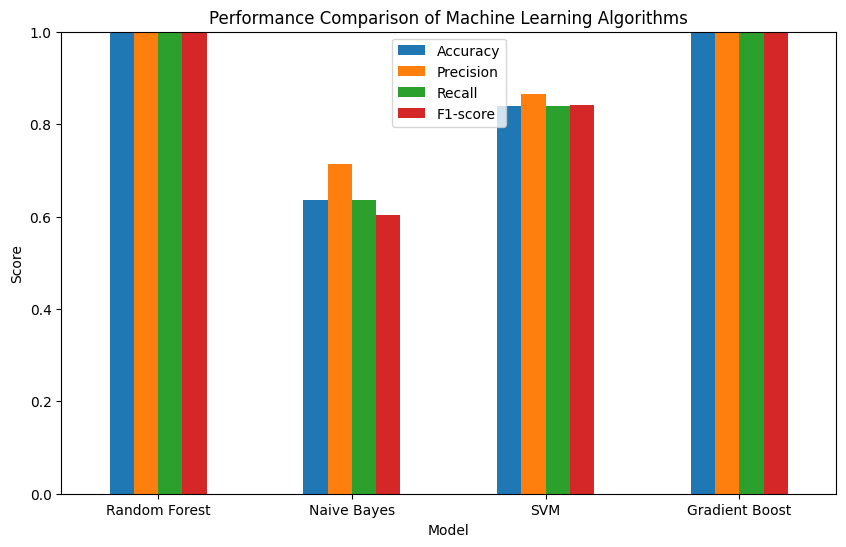

In [27]:
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison of Machine Learning Algorithms")

plt.ylabel("Score")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()


Save โมเดลทั้งหมด

In [28]:
import joblib

joblib.dump(rf,"rf_model.pkl")
joblib.dump(nb,"nb_model.pkl")
joblib.dump(svm,"svm_model.pkl")
joblib.dump(gb,"gb_model.pkl")


['gb_model.pkl']

Load โมเดล

In [ ]:
import joblib

rf = joblib.load("rf_model.pkl")
nb = joblib.load("nb_model.pkl")
svm = joblib.load("svm_model.pkl")
gb = joblib.load("gb_model.pkl")


ทำนายข้อมูลใหม่ด้วยทุกโมเดล

In [ ]:
sample = X_test.iloc[[0]]

print("Random Forest:", rf.predict(sample))
print("Naive Bayes:", nb.predict(sample))
print("SVM:", svm.predict(sample))
print("Gradient Boost:", gb.predict(sample))


แปลงกลับเป็นชื่อ Attack

In [ ]:
print("Random Forest:", le.inverse_transform(rf.predict(sample)))
print("Naive Bayes:", le.inverse_transform(nb.predict(sample)))
print("SVM:", le.inverse_transform(svm.predict(sample)))
print("Gradient Boost:", le.inverse_transform(gb.predict(sample)))


ทดลองกับหลาย record

In [ ]:
samples = X_test.iloc[0:5]

for name, model in models.items():

    pred = model.predict(samples)

    attack = le.inverse_transform(pred)

    print(name)
    print(attack)
